Imports and Load Data Set


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

path = path + '/etfs'
all_files = glob.glob(os.path.join(path, "*.csv"))

100%|██████████| 522M/522M [00:07<00:00, 72.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


The dataset contains stocks and ETFs - we want to specifically look at ETFs

In [12]:
#finds the largest file we want
max_rows = 0
max_df = None
max_file = None
for file in all_files:
    df = pd.read_csv(file)
    df = df[df['Open'] != 0] #remove lines where open == 0
    df = df.drop(columns=['Date']) #drops the date column completely, will deal with this later
    if len(df) > max_rows:
      max_rows = len(df)
      max_df = df
      max_file = file
print("Data Frame: \n" , max_df.head(), "\nRows: " , max_rows, "\nFile: " , max_file)

Data Frame: 
         Open    High     Low   Close  Adj Close  Volume
1417  3.9375  3.9375  3.8750  3.8750   3.728003   10900
1418  3.8750  3.9375  3.8750  3.9375   3.788132   25500
1419  3.9375  4.0000  3.8750  3.9375   3.788132   21600
1420  3.8750  3.9375  3.8750  3.9375   3.788132   30000
1421  3.9375  4.1250  3.9375  4.1250   3.968519   81100 
Rows:  7151 
File:  /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/etfs/CEF.csv


# Catboost stuff below

In [34]:
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score

# convert prices to % returns to see how much price changed from yesterday
df = max_df
df['Open_Pct']   = df['Open'].pct_change()
df['High_Pct']   = df['High'].pct_change()
df['Low_Pct']    = df['Low'].pct_change()
df['Close_Pct']  = df['Close'].pct_change()
df['Volume_Pct'] = df['Volume'].pct_change()

# predict next day's close return by shifting column up by 1
# this means: use today's data (row i) to predict tomorrow's return (row i+1)
df['Target_Next_Day_Return'] = df['Close_Pct'].shift(-1)
df = df.dropna() # remove bad columns

# 5. Define X and y using the NEW features
features = ['Open_Pct', 'High_Pct', 'Low_Pct', 'Close_Pct', 'Volume_Pct']
X = df[features]
y = df['Target_Next_Day_Return']

#this splits the data for train and test
#shuffle = false make its chronological where train is older than test
#shuffle = true makes it random
#not sure which to choose since having it random leads to data leakage / memorization between open and closes between days
#but leaving it chronological means if the stock goes up and the train data was never tested with numbers that high itll max out and have a really bad r2 score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True)

print("starting best parameter search")

param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

base_model = CatBoostRegressor(
    iterations = 500,
    loss_function = 'RMSE',
    random_seed = 96594,
    verbose = 0,
    allow_writing_files = False
)

grid_search = GridSearchCV(
    estimator = base_model,
    param_grid = param_grid,
    #cv = TimeSeriesSplit(n_splits=3), #chronological splits
    cv = 3, #random splits
    scoring = 'r2',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print(f"best r2 score: {grid_search.best_score_:.4f}")
print("best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_

importance = best_model.get_feature_importance()
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'score': importance})

importance_df = importance_df.sort_values(by='score', ascending=False)
print(importance_df)

low_impact_features = importance_df[importance_df['score'] < 5.0]['feature'].tolist()
print(f"dropping {len(low_impact_features)} features: {low_impact_features}")

X_train_reduced = X_train.drop(columns=low_impact_features)
X_test_reduced = X_test.drop(columns=low_impact_features)

starting best parameter search
best r2 score: 0.0043
best parameters found: {'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
      feature      score
3   Close_Pct  40.603375
1    High_Pct  16.812953
0    Open_Pct  15.450781
2     Low_Pct  15.153466
4  Volume_Pct  11.979426
dropping 0 features: []


In [35]:
print("training best model on full reduced dataset")
best_model.fit(X_train_reduced, y_train)
y_pred = best_model.predict(X_test_reduced)

score = r2_score(y_test, y_pred)
print("test R2 Score:", score)

training best model on full reduced dataset
test R2 Score: 0.01899986628921746


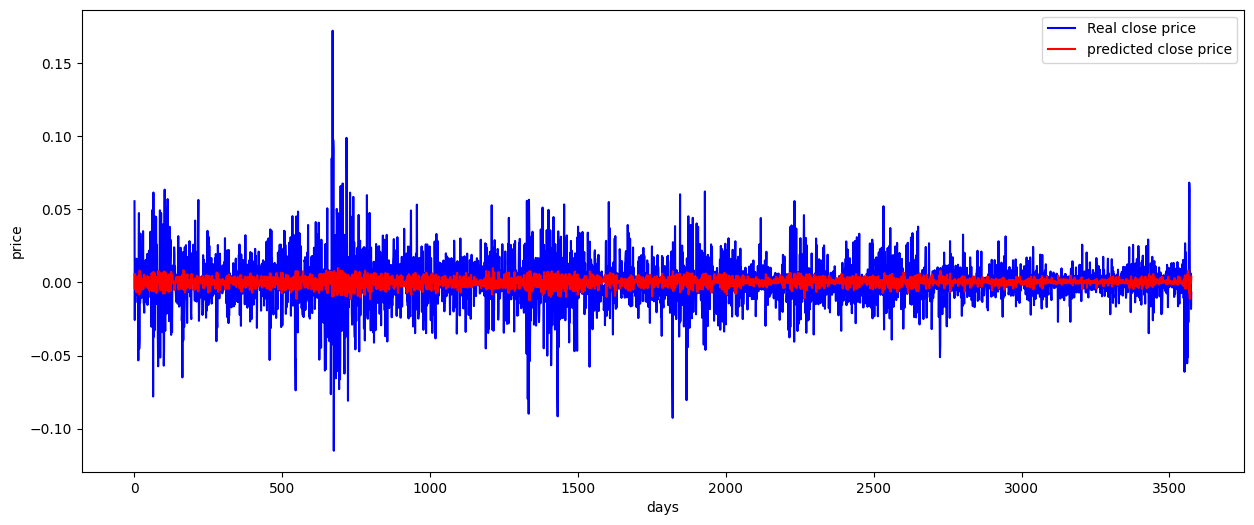

In [33]:
#plots y_pred vs y_test
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Real close price', color='blue')
plt.plot(y_pred, label='predicted close price', color='red')
plt.xlabel("days")
plt.ylabel("price")
plt.legend()
plt.show()

# Neural Networks stuff below

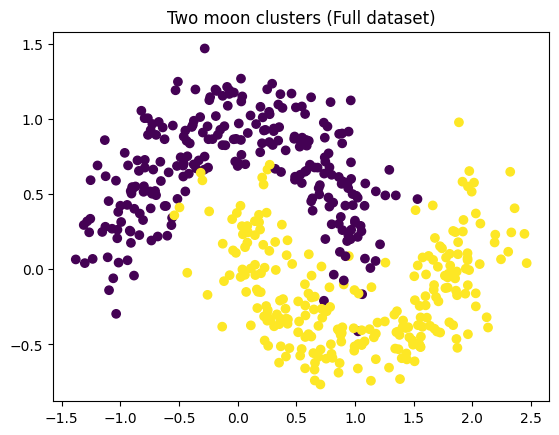

In [ ]:
import sklearn.datasets
import sklearn.metrics
import tensorflow

X, y = sklearn.datasets.make_moons(n_samples=500, noise=0.19, random_state=96594) #TODO: Change random_state to the last 5 digits of your BuffOne card
X_train, y_train = X[:350], y[:350]
X_test, y_test = X[350:], y[350:]
plt.title("Two moon clusters (Full dataset)")
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

def show_decision_surface(model):
    """
    Helper function to visualize the decision surface of model
    :param model: Initialized Classifier
    :return: None
    """
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    x_grid = np.arange(x_min, x_max, 0.1)
    y_grid = np.arange(y_min, y_max, 0.1)
    xx, yy = np.meshgrid(x_grid, y_grid)
    r1, r2 = xx.reshape(-1,1), yy.reshape(-1,1)
    grid = np.hstack((r1,r2))
    y_hat = model.predict(grid)
    zz = y_hat.reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap='PiYG')
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.show()

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6817  
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5815 
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5005 
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4498 
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3852 
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3598 
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3106 
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3231  
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3297 
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2609 
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2328 
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2878 
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2134 
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2272 
Epoch 15/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2296 
Ep

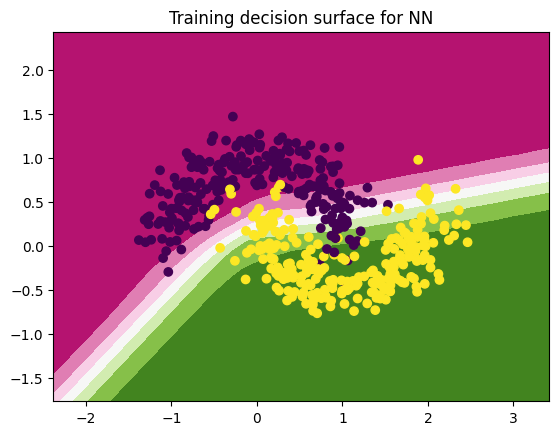

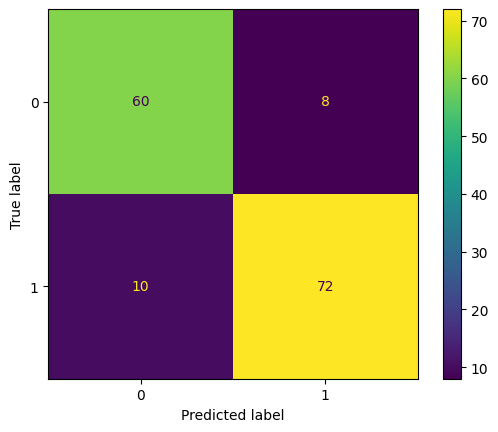

Accuracy: 0.88


In [ ]:
model = tensorflow.keras.models.Sequential( [
    tensorflow.keras.layers.InputLayer(shape=(2,)),
    tensorflow.keras.layers.Dense(50, activation = "relu"),
    tensorflow.keras.layers.Dense(50, activation = "relu"),
    tensorflow.keras.layers.Dense(1, activation="sigmoid")
] )

model.compile(loss="BinaryCrossentropy")

model.fit(X_train, y_train, epochs=20)
score = model.evaluate(X_test, y_test, verbose=0)

y_pred = (model.predict(X_test) > 0.5).astype("int32")

plt.title("Training decision surface for NN")
show_decision_surface(model)
conf = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(conf)
disp.plot()
plt.show()
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
print("Accuracy:" , accuracy)